In [1]:
import pandas as pd

# Loading the dataset
df = pd.read_csv('political_leaning.csv')

# Displaying the dataset
print(df.shape)

df.head(15)

(57231, 3)


,auhtor_ID,post,political_leaning
0,t2_7ramzeng,"You can ""buy"" the show and stream it through t...",right
1,t2_7ramzeng,"me want to play Q*bert Holy shit, based Alex J...",right
2,t2_7ramzeng,Shouldn't rely on any external services or per...,right
3,t2_7ramzeng,PR to a specific person. Usually that just mea...,right
4,t2_7ramzeng,This article's intention is clear that they wa...,right
5,t2_7ramzeng,is big and a safe investment (by pretending th...,right
6,t2_7ramzeng,"but that seems even less likely. No, that is a...",right
7,t2_7ramzeng,were living paycheck to paycheck without diffi...,right
8,t2_7ramzeng,This one takes experience to learn how to poin...,right
9,t2_7ramzeng,gloves drops a bag of food in front of the car...,right


In [2]:
# Removing the center class

# Keeping only left and right class
df_filtered = df[df["political_leaning"].isin(["left", "right"])].copy()

print("After keeping only left/right:", df_filtered.shape)
print(df_filtered["political_leaning"].value_counts())

After keeping only left/right: (32030, 3)
political_leaning
right    17454
left     14576
Name: count, dtype: int64


In [3]:
# Rename the author_id column 

df_filtered = df_filtered.rename(columns={'auhtor_ID': 'author_ID'})

df_filtered.info()
df_filtered.head()

<class 'pandas.core.frame.DataFrame'>
Index: 32030 entries, 0 to 57134
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   author_ID          32030 non-null  object
 1   post               32030 non-null  object
 2   political_leaning  32030 non-null  object
dtypes: object(3)
memory usage: 1000.9+ KB


,author_ID,post,political_leaning
0,t2_7ramzeng,"You can ""buy"" the show and stream it through t...",right
1,t2_7ramzeng,"me want to play Q*bert Holy shit, based Alex J...",right
2,t2_7ramzeng,Shouldn't rely on any external services or per...,right
3,t2_7ramzeng,PR to a specific person. Usually that just mea...,right
4,t2_7ramzeng,This article's intention is clear that they wa...,right


In [4]:
import re

def preprocess_text(text):
    # 1) lowercase
    text = str(text).lower()
    
    # 2) Deleting URL
    text = re.sub(r'http\S+', '', text)
    
    # 3) Deleting non word and non white space (punctuation)
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # 4) Deleting numbers
    text = re.sub(r'\d+', ' ', text)
    
    # 5) Fixing the spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


In [5]:
# Applying pre processing to the post column
df_filtered['post_cleaned'] = df_filtered['post'].apply(preprocess_text)

df_filtered[['post', 'post_cleaned']].head()


,post,post_cleaned
0,"You can ""buy"" the show and stream it through t...",you can buy the show and stream it through the...
1,"me want to play Q*bert Holy shit, based Alex J...",me want to play q bert holy shit based alex jo...
2,Shouldn't rely on any external services or per...,shouldn t rely on any external services or per...
3,PR to a specific person. Usually that just mea...,pr to a specific person usually that just mean...
4,This article's intention is clear that they wa...,this article s intention is clear that they wa...


In [6]:
# Dropping the old post column
df_filtered = df_filtered.drop(columns=['post'])

# Ordering the columns again
df_filtered = df_filtered[['author_ID', 'post_cleaned', 'political_leaning']]

df_filtered.head()


,author_ID,post_cleaned,political_leaning
0,t2_7ramzeng,you can buy the show and stream it through the...,right
1,t2_7ramzeng,me want to play q bert holy shit based alex jo...,right
2,t2_7ramzeng,shouldn t rely on any external services or per...,right
3,t2_7ramzeng,pr to a specific person usually that just mean...,right
4,t2_7ramzeng,this article s intention is clear that they wa...,right


In [7]:
# Saving the filtered dataset in order to use it later
df_filtered.to_csv('df_filtered_cleaned.csv', index=False)
print("Saved cleaned dataset to df_filtered_cleaned.csv")


Saved cleaned dataset to df_filtered_cleaned.csv


EDA

political_leaning
right    17454
left     14576
Name: count, dtype: int64
political_leaning
right    0.544927
left     0.455073
Name: proportion, dtype: float64


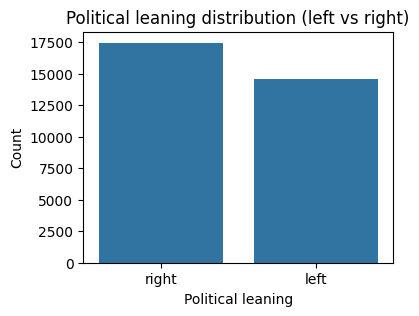

In [8]:
# Distribution of left and right class
import seaborn as sns
import matplotlib.pyplot as plt

print(df_filtered['political_leaning'].value_counts())
print(df_filtered['political_leaning'].value_counts(normalize=True))

plt.figure(figsize=(4,3))
sns.countplot(data=df_filtered, x='political_leaning')
plt.title("Political leaning distribution (left vs right)")
plt.xlabel("Political leaning")
plt.ylabel("Count")
plt.show()


Top LEFT words: [('the', 854723), ('to', 534273), ('a', 506010), ('i', 437086), ('and', 434521), ('it', 388714), ('of', 381976), ('that', 358181), ('you', 335241), ('is', 322827)]
Top RIGHT words: [('the', 1032538), ('to', 644941), ('a', 609987), ('i', 523794), ('and', 520228), ('of', 446760), ('it', 445427), ('you', 417867), ('is', 398549), ('that', 396601)]


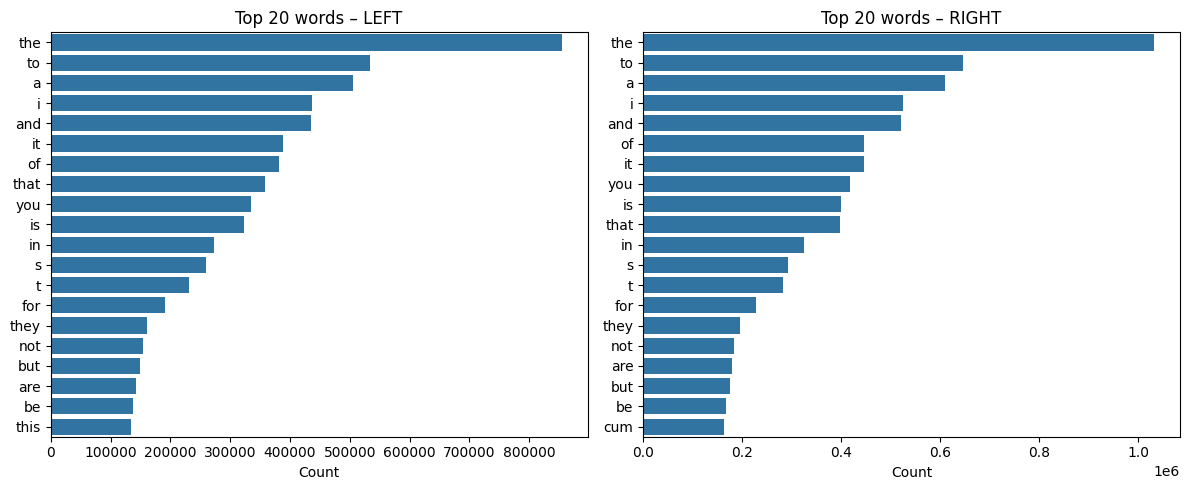

In [9]:
from collections import Counter

def top_k_words(texts, k=30):
    tokens = " ".join(texts).split()
    counter = Counter(tokens)
    return counter.most_common(k)

left_texts  = df_filtered[df_filtered['political_leaning']=='left']['post_cleaned']
right_texts = df_filtered[df_filtered['political_leaning']=='right']['post_cleaned']

top_left  = top_k_words(left_texts, k=20)
top_right = top_k_words(right_texts, k=20)

print("Top LEFT words:", top_left[:10])
print("Top RIGHT words:", top_right[:10])

left_words, left_counts = zip(*top_left)
right_words, right_counts = zip(*top_right)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.barplot(x=list(left_counts), y=list(left_words))
plt.title("Top 20 words – LEFT")
plt.xlabel("Count")

plt.subplot(1,2,2)
sns.barplot(x=list(right_counts), y=list(right_words))
plt.title("Top 20 words – RIGHT")
plt.xlabel("Count")

plt.tight_layout()
plt.show()


In [10]:
# Inspecting European political keywords dataset
import pandas as pd

# Load EU keywords file
eu_keywords = pd.read_csv("eu-political-barometer_keywords_2024_v01.csv")

print("Shape:", eu_keywords.shape)
print("\nColumns:")
print(eu_keywords.columns)

print("\nInfo:")
eu_keywords.info()

eu_keywords.head(15)

Shape: (15927046, 4)

Columns:
Index(['party_id', 'word', 'week', 'freq'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15927046 entries, 0 to 15927045
Data columns (total 4 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   party_id  int64 
 1   word      object
 2   week      object
 3   freq      int64 
dtypes: int64(2), object(2)
memory usage: 486.1+ MB


,party_id,word,week,freq
0,2612,accord,2021-10-10,1
1,2612,afraid,2021-10-10,1
2,2612,anyone,2021-10-10,1
3,2612,anywhere,2021-10-10,1
4,2612,ban,2021-10-10,1
5,2612,budget,2021-10-10,1
6,2612,case,2021-10-10,1
7,2612,confirm,2021-10-10,1
8,2612,convict,2021-10-10,1
9,2612,criminal,2021-10-10,1


In [11]:
# Dropping the party_id, week and frequ columns

eu_keywords = eu_keywords.drop(columns=["party_id", "week", "freq"])

# Check result
print(eu_keywords.shape)
print(eu_keywords.columns)
eu_keywords.head(15)

(15927046, 1)
Index(['word'], dtype='object')


,word
0,accord
1,afraid
2,anyone
3,anywhere
4,ban
5,budget
6,case
7,confirm
8,convict
9,criminal


In [12]:
# Inspecting Harvard Dictionary

# Load Harvard lexicon 
harvard_lexicon = pd.read_csv("lexicon.csv", header=None, names=["word"])

harvard_lexicon.head(10)

,word
0,ADMINISTRATION
1,ADVERSARY
2,ALLIANCE
3,ALLIED
4,ALLY
5,AMBASSADOR
6,AMENDMENT
7,ANARCHIST
8,ANARCHY
9,ANTITRUST


In [13]:
# Making the words lowercase

harvard_lexicon["word"] = harvard_lexicon["word"].str.lower()

# Check
print(harvard_lexicon.shape)
harvard_lexicon.head(10)

(94, 1)


,word
0,administration
1,adversary
2,alliance
3,allied
4,ally
5,ambassador
6,amendment
7,anarchist
8,anarchy
9,antitrust


POLITICAL LEXICON RATIO BY CLASS

In [14]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Combine EU and Harvard lexicons
eu_lex = set(eu_keywords["word"])
harvard_lex = set(harvard_lexicon["word"])

lex_all = eu_lex.union(harvard_lex)

# Minimal filtering: remove stopwords and very short tokens
lex_all_filtered = {
    word for word in lex_all
    if word not in ENGLISH_STOP_WORDS and len(str(word)) > 2
}

print("Original combined lexicon size:", len(lex_all))
print("Filtered lexicon size:", len(lex_all_filtered))

Original combined lexicon size: 20341
Filtered lexicon size: 19998


In [15]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Combine EU and Harvard lexicons
eu_lex = set(eu_keywords["word"])
harvard_lex = set(harvard_lexicon["word"])

lex_all = eu_lex.union(harvard_lex)

# Minimal filtering: remove stopwords and very short tokens
lex_all_filtered = {
    word for word in lex_all
    if word not in ENGLISH_STOP_WORDS and len(str(word)) > 2
}

print("Original combined lexicon size:", len(lex_all))
print("Filtered lexicon size:", len(lex_all_filtered))

Original combined lexicon size: 20341
Filtered lexicon size: 19998


In [16]:
def political_stats(text, lexicon):
    tokens = text.split()
    total = len(tokens)
    pol = sum(1 for token in tokens if token in lexicon)
    ratio = pol / total if total > 0 else 0.0
    return total, pol, ratio 

df_filtered[["total_tokens", "pol_tokens", "pol_ratio"]] = df_filtered["post_cleaned"].apply(
    lambda text: pd.Series(political_stats(text, lex_all_filtered))
)

# total_tokens = total number of words in each post
# pol_tokens   = number of words in each post that appear in the political lexicon
# pol_ratio    = proportion of political lexicon words in each post

df_filtered[["post_cleaned", "total_tokens", "pol_tokens", "pol_ratio", "political_leaning"]].head()

,post_cleaned,total_tokens,pol_tokens,pol_ratio,political_leaning
0,you can buy the show and stream it through the...,1546.0,384.0,0.248383,right
1,me want to play q bert holy shit based alex jo...,1568.0,433.0,0.276148,right
2,shouldn t rely on any external services or per...,1569.0,416.0,0.265137,right
3,pr to a specific person usually that just mean...,1558.0,400.0,0.256739,right
4,this article s intention is clear that they wa...,1553.0,396.0,0.254990,right


In [17]:
political_ratio_summary = df_filtered.groupby("political_leaning")[["total_tokens", "pol_tokens", "pol_ratio"]].mean()

political_ratio_summary

,total_tokens,pol_tokens,pol_ratio
political_leaning,,,
left,1523.270856,372.727566,0.244624
right,1520.288072,374.876074,0.246463


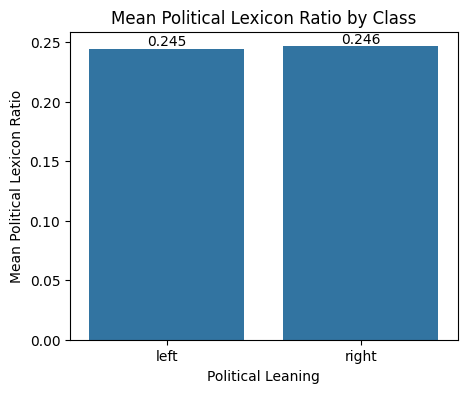

In [18]:
summary_plot = df_filtered.groupby("political_leaning", as_index=False)["pol_ratio"].mean()

plt.figure(figsize=(5, 4))

sns.barplot(
    data=summary_plot,
    x="political_leaning",
    y="pol_ratio"
)

plt.title("Mean Political Lexicon Ratio by Class")
plt.xlabel("Political Leaning")
plt.ylabel("Mean Political Lexicon Ratio")

for index, row in summary_plot.iterrows():
    plt.text(
        index,
        row["pol_ratio"],
        round(row["pol_ratio"], 3),
        ha="center",
        va="bottom"
    )

plt.show()

In [19]:
# Number of posts per author

posts_per_author = df_filtered.groupby(["author_ID", "political_leaning"]).size().reset_index(name="post_count")

posts_per_author.head()

,author_ID,political_leaning,post_count
0,t2_103jrs,left,2
1,t2_103pns,right,14
2,t2_105gpn,left,2
3,t2_1084ts,left,14
4,t2_10lvbi,right,74


In [20]:
posts_per_author.groupby("political_leaning")["post_count"].describe()

,count,mean,std,min,25%,50%,75%,max
political_leaning,,,,,,,,
left,560.0,26.028571,44.636066,1.0,4.0,11.0,29.25,412.0
right,735.0,23.746939,45.211235,1.0,4.0,10.0,26.00,571.0


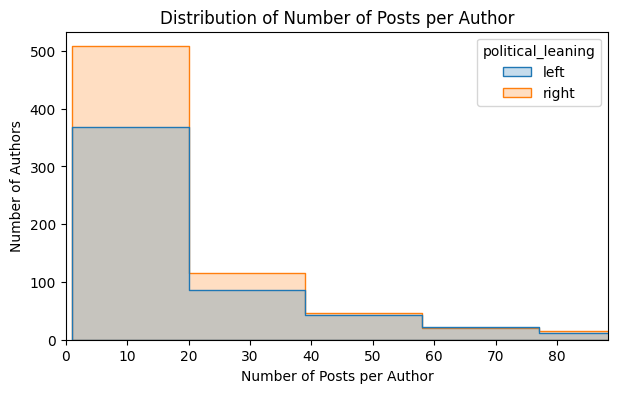

In [21]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=posts_per_author,
    x="post_count",
    hue="political_leaning",
    bins=30,
    element="step"
)

plt.title("Distribution of Number of Posts per Author")
plt.xlabel("Number of Posts per Author")
plt.ylabel("Number of Authors")
plt.xlim(0, posts_per_author["post_count"].quantile(0.95))

plt.show()

In [22]:
import pandas as pd
import numpy as np

df_filtered = pd.read_csv("df_filtered_cleaned.csv")

print(df_filtered.columns.tolist())
print("\nShape:", df_filtered.shape)

required_columns = ["author_ID", "post_cleaned", "political_leaning"]

for col in required_columns:
    print(col, "missing:", df_filtered[col].isna().sum())

print("\nPolitical leaning counts:")
print(df_filtered["political_leaning"].value_counts())

print("\nPolitical leaning proportions:")
print(df_filtered["political_leaning"].value_counts(normalize=True))

df_filtered["post_cleaned_len_chars"] = df_filtered["post_cleaned"].astype(str).str.len()
df_filtered["post_cleaned_len_words"] = df_filtered["post_cleaned"].astype(str).str.split().str.len()

print("\nChar length describe:")
print(df_filtered["post_cleaned_len_chars"].describe())

print("\nWord length describe:")
print(df_filtered["post_cleaned_len_words"].describe())

author_post_counts = df_filtered.groupby("author_ID").size().sort_values(ascending=False)

print("\nAuthor post count describe:")
print(author_post_counts.describe())

print("\nTop 20 authors by post count:")
print(author_post_counts.head(20))

author_label_counts = df_filtered.groupby("author_ID")["political_leaning"].nunique()

print("\nAuthors with >1 unique political label:",
      (author_label_counts > 1).sum())

n_total = len(df_filtered)
n_unique_posts = df_filtered["post_cleaned"].nunique()

print("\nTotal rows:", n_total)
print("Unique post_cleaned rows:", n_unique_posts)
print("Duplicate rate:", 1 - (n_unique_posts / n_total))

pd.set_option("display.max_colwidth", 500)

print("\nSample cleaned texts:")
print(df_filtered[["author_ID", "political_leaning", "post_cleaned"]].sample(20, random_state=42))

print("\nPreview object columns:")
for col in df_filtered.columns:
    if df_filtered[col].dtype == "object":
        print("\nCOLUMN:", col)
        try:
            print(df_filtered[col].dropna().astype(str).iloc[0][:300])
        except:
            print("Could not preview")

['author_ID', 'post_cleaned', 'political_leaning']

Shape: (32030, 3)
author_ID missing: 0
post_cleaned missing: 0
political_leaning missing: 0

Political leaning counts:
political_leaning
right    17454
left     14576
Name: count, dtype: int64

Political leaning proportions:
political_leaning
right    0.544927
left     0.455073
Name: proportion, dtype: float64

Char length describe:
count    32030.000000
mean      8029.518826
std        796.682933
min       1457.000000
25%       7899.000000
50%       8111.000000
75%       8337.000000
max      12471.000000
Name: post_cleaned_len_chars, dtype: float64

Word length describe:
count    32030.000000
mean      1521.645457
std        134.668881
min        272.000000
25%       1527.000000
50%       1543.000000
75%       1557.000000
max       2305.000000
Name: post_cleaned_len_words, dtype: float64

Author post count describe:
count    1295.000000
mean       24.733591
std        44.960322
min         1.000000
25%         4.000000
50%        10.